# Matching - PySpark version

In [1]:
# matching.py

import os
import json
import numpy as np
import pandas as pd

from typing import List, Optional, Dict, Any

from pyspark.sql import DataFrame, Window
from pyspark.sql import functions as F

StatementMeta(, a57580c7-f5c0-4acb-8eeb-e0abfe7b7b4f, 3, Finished, Available, Finished, False)

In [2]:
%run ./matching

StatementMeta(, a57580c7-f5c0-4acb-8eeb-e0abfe7b7b4f, 4, Finished, Available, Finished, True)

## Load Data

In [3]:
month_result= pd.read_parquet("/lakehouse/default/Files/month_data")
month_result_all= month_result[month_result["price"]== "all"] 
print(month_result.shape)
print(month_result_all.shape)
month_result_spark= spark.createDataFrame(month_result_all)

StatementMeta(, a57580c7-f5c0-4acb-8eeb-e0abfe7b7b4f, 5, Finished, Available, Finished, False)

(4538578, 17)
(1854385, 17)


## Matching


In [4]:
print("Running time series matching...")

res_ts = run_time_series_matching_pipeline(
    sdf=month_result_spark,
    output_folder="Files/output/matching/time_series",
    lookback_months=12,
    verbose=True,
    save_output=False,
    control_type="never_treated"
)

# res_ts["balance"].show(5)

StatementMeta(, a57580c7-f5c0-4acb-8eeb-e0abfe7b7b4f, 6, Finished, Available, Finished, False)

Running time series matching...
Preparing base dataframe ...
Building risk set rows ...
risk_rows count = 5684081
+----------+-------+------+
|Ti        |group  |count |
+----------+-------+------+
|2025-03-01|control|566104|
|2025-03-01|treated|7495  |
|2025-04-01|control|566173|
|2025-04-01|treated|4008  |
|2025-05-01|control|566246|
|2025-05-01|treated|1680  |
|2025-06-01|control|566314|
|2025-06-01|treated|1500  |
|2025-07-01|control|566371|
|2025-07-01|treated|768   |
|2025-08-01|control|566423|
|2025-08-01|treated|480   |
|2025-09-01|control|566472|
|2025-09-01|treated|588   |
|2025-10-01|control|566514|
|2025-10-01|treated|600   |
|2025-11-01|control|566547|
|2025-11-01|treated|1773  |
|2025-12-01|control|566573|
|2025-12-01|treated|1452  |
+----------+-------+------+

Building fixed-lag time series profiles ...
profiles count = 473275
Standardizing by controls ...
profiles_z count = 473275
Matching top-k ...
matches count = 8470
Building matched profiles ...
matched_profiles co

StatementMeta(, a57580c7-f5c0-4acb-8eeb-e0abfe7b7b4f, 7, Finished, Available, Finished, False)

Saving parquet to Files/output/matching/time_series ...
✅ Save completed


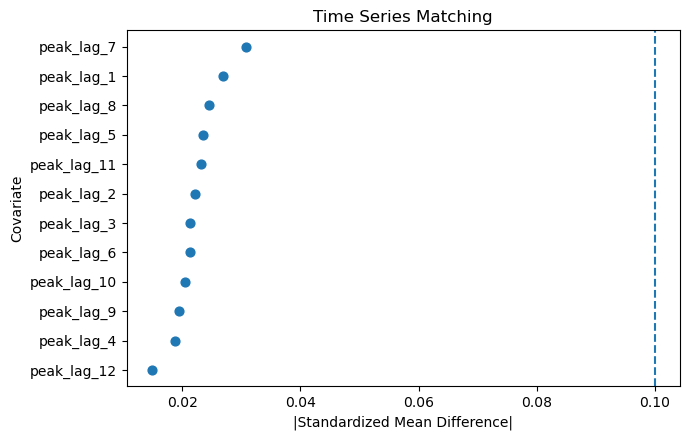

In [5]:
save_matching_results_fabric(
    res=res_ts,
    folder="Files/output/matching/time_series",
    config={
        "type": "time_series",
        "lookback_months": 12
    },
)

love_plot_from_spark(
    res_ts["balance"],
    output_path=None, 
    title="Time Series Matching"
)

In [6]:
check_balance_full_safe(res_ts)

StatementMeta(, a57580c7-f5c0-4acb-8eeb-e0abfe7b7b4f, 8, Finished, Available, Finished, False)

Rebuilding summary profiles for validation...
Matched profiles count = 9803

(No matching variables available in summary space)

--------------------------------------------------

=== NON-MATCHING VARIABLES (MAIN VALIDATION) ===
+--------------------+-------------------+-------------------+--------------------+
|covariate           |treated_mean       |control_mean       |SMD                 |
+--------------------+-------------------+-------------------+--------------------+
|peak_mean           |6.3069963082939795 |6.229335674908542  |0.02469381450984776 |
|peak_sd             |1.4089585090897383 |1.2534509303377603 |0.16440526379578074 |
|peak_volatility     |0.9090678685199098 |0.7240133473469434 |0.35991941622554896 |
|mean_consumption    |1.3375387912036316 |1.4947355607441006 |-0.21247002574759308|
|variance_consumption|1.6656774782749597 |1.4939858147951661 |0.10715691591026776 |
|total_consumption   |38421.75666115703  |42518.63410654827  |-0.19729874583230295|
|trend        

StatementMeta(, a57580c7-f5c0-4acb-8eeb-e0abfe7b7b4f, 9, Finished, Available, Finished, False)

Running summary matching 1...
Preparing base dataframe ...
Building risk set rows ...
risk_rows count = 5684081
+----------+-------+------+
|Ti        |group  |count |
+----------+-------+------+
|2025-03-01|control|566104|
|2025-03-01|treated|7495  |
|2025-04-01|control|566173|
|2025-04-01|treated|4008  |
|2025-05-01|control|566246|
|2025-05-01|treated|1680  |
|2025-06-01|control|566314|
|2025-06-01|treated|1500  |
|2025-07-01|control|566371|
|2025-07-01|treated|768   |
|2025-08-01|control|566423|
|2025-08-01|treated|480   |
|2025-09-01|control|566472|
|2025-09-01|treated|588   |
|2025-10-01|control|566514|
|2025-10-01|treated|600   |
|2025-11-01|control|566547|
|2025-11-01|treated|1773  |
|2025-12-01|control|566573|
|2025-12-01|treated|1452  |
+----------+-------+------+

Building summary profiles ...
profiles count = 473947
Standardizing by controls ...
profiles_z count = 473947
Matching top-k ...
matches count = 8480
Building matched profiles ...
matched_profiles count = 9811
Compu

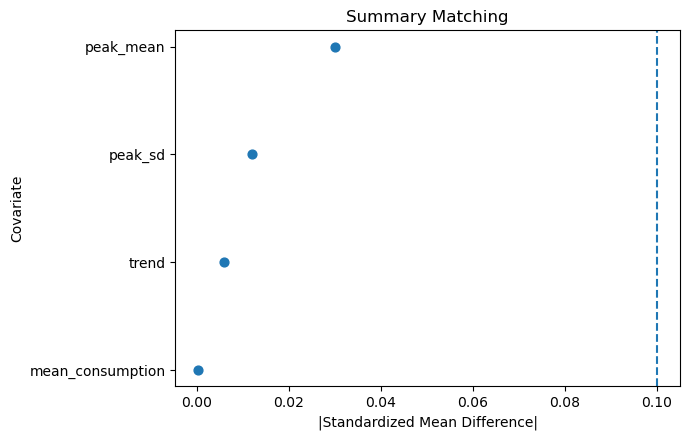

Rebuilding summary profiles for validation...
Matched profiles count = 9811

=== MATCHING VARIABLES ===
+----------------+-------------------+-------------------+--------------------+
|covariate       |treated_mean       |control_mean       |SMD                 |
+----------------+-------------------+-------------------+--------------------+
|peak_mean       |6.3093479367395755 |6.215185992797768  |0.029945161917636437|
|mean_consumption|1.337627547559283  |1.3374221908210386 |3.066475073459489E-4|
|peak_sd         |1.408372294048179  |1.3967309398800911 |0.012020105311049776|
|trend           |0.09942157383354663|0.09780877338161742|0.005940199104289608|
+----------------+-------------------+-------------------+--------------------+


--------------------------------------------------

=== NON-MATCHING VARIABLES (MAIN VALIDATION) ===
+--------------------+------------------+------------------+--------------------+
|covariate           |treated_mean      |control_mean      |SMD        

In [7]:
print("Running summary matching 1...")

res_summary_1 = run_summary_matching_pipeline(
    sdf=month_result_spark,
    output_folder="Files/output/matching/summary_1",
    lookback_months=12,
    summary_vars=[
        "peak_mean",
        "mean_consumption",
        "peak_sd",
        "trend"
    ],
    verbose=True,
    save_output=False,
    control_type="never_treated"
)

# res_summary_1["balance"].show(5)

save_matching_results_fabric(
    res=res_summary_1,
    folder="Files/output/matching/summary_1",
    config={
        "type": "summary",
        "vars": ["peak_mean","mean_consumption","peak_sd","trend"]
    },
)

love_plot_from_spark(
    res_summary_1["balance"],
    output_path=None, 
    title="Summary Matching")


check_balance_full_safe(res_summary_1)

StatementMeta(, a57580c7-f5c0-4acb-8eeb-e0abfe7b7b4f, 10, Finished, Available, Finished, False)

Running summary matching 2...
Preparing base dataframe ...
Building risk set rows ...
risk_rows count = 5684081
+----------+-------+------+
|Ti        |group  |count |
+----------+-------+------+
|2025-03-01|control|566104|
|2025-03-01|treated|7495  |
|2025-04-01|control|566173|
|2025-04-01|treated|4008  |
|2025-05-01|control|566246|
|2025-05-01|treated|1680  |
|2025-06-01|control|566314|
|2025-06-01|treated|1500  |
|2025-07-01|control|566371|
|2025-07-01|treated|768   |
|2025-08-01|control|566423|
|2025-08-01|treated|480   |
|2025-09-01|control|566472|
|2025-09-01|treated|588   |
|2025-10-01|control|566514|
|2025-10-01|treated|600   |
|2025-11-01|control|566547|
|2025-11-01|treated|1773  |
|2025-12-01|control|566573|
|2025-12-01|treated|1452  |
+----------+-------+------+

Building summary profiles ...
profiles count = 473947
Standardizing by controls ...
profiles_z count = 473947
Matching top-k ...
matches count = 8480
Building matched profiles ...
matched_profiles count = 9720
Compu

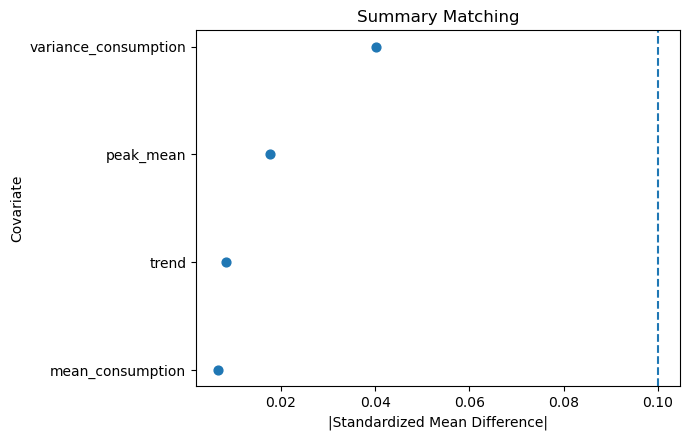

Rebuilding summary profiles for validation...
Matched profiles count = 9720

=== MATCHING VARIABLES ===
+--------------------+-------------------+-------------------+--------------------+
|covariate           |treated_mean       |control_mean       |SMD                 |
+--------------------+-------------------+-------------------+--------------------+
|peak_mean           |6.3093479367395755 |6.253501157071184  |0.017671880315764353|
|mean_consumption    |1.3376275475592827 |1.333159993363968  |0.006672503689093681|
|variance_consumption|1.6668940160750696 |1.60224491193038   |0.04010553435492712 |
|trend               |0.09942157383354663|0.09718841625020044|0.008258014438384347|
+--------------------+-------------------+-------------------+--------------------+


--------------------------------------------------

=== NON-MATCHING VARIABLES (MAIN VALIDATION) ===
+-----------------+------------------+------------------+--------------------+
|covariate        |treated_mean      |cont

In [8]:
print("Running summary matching 2...")

res_summary_2 = run_summary_matching_pipeline(
    sdf=month_result_spark,
    output_folder="Files/output/matching/summary_2",
    lookback_months=12,
    summary_vars=[
        "peak_mean",
        "mean_consumption",
        "variance_consumption",
        "trend"
    ],
    verbose=True,
    save_output=False,
    control_type="never_treated"
)

# res_summary_2["balance"].show(5)

save_matching_results_fabric(
    res=res_summary_2,
    folder="Files/output/matching/summary_2",
    config={
        "type": "summary",
        "vars": ["peak_mean","mean_consumption","variance_consumption","trend"]
    },
)

love_plot_from_spark(
    res_summary_2["balance"],
    output_path=None, 
    title="Summary Matching"
)


check_balance_full_safe(res_summary_2)

StatementMeta(, a57580c7-f5c0-4acb-8eeb-e0abfe7b7b4f, 11, Finished, Available, Finished, False)

Running summary matching 3...
Preparing base dataframe ...
Building risk set rows ...
risk_rows count = 5684081
+----------+-------+------+
|Ti        |group  |count |
+----------+-------+------+
|2025-03-01|control|566104|
|2025-03-01|treated|7495  |
|2025-04-01|control|566173|
|2025-04-01|treated|4008  |
|2025-05-01|control|566246|
|2025-05-01|treated|1680  |
|2025-06-01|control|566314|
|2025-06-01|treated|1500  |
|2025-07-01|control|566371|
|2025-07-01|treated|768   |
|2025-08-01|control|566423|
|2025-08-01|treated|480   |
|2025-09-01|control|566472|
|2025-09-01|treated|588   |
|2025-10-01|control|566514|
|2025-10-01|treated|600   |
|2025-11-01|control|566547|
|2025-11-01|treated|1773  |
|2025-12-01|control|566573|
|2025-12-01|treated|1452  |
+----------+-------+------+

Building summary profiles ...
profiles count = 473947
Standardizing by controls ...
profiles_z count = 473947
Matching top-k ...
matches count = 8480
Building matched profiles ...
matched_profiles count = 9887
Compu

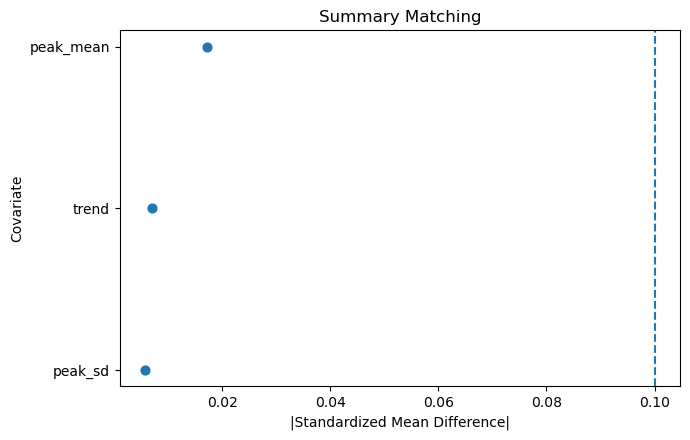

Rebuilding summary profiles for validation...
Matched profiles count = 9887

=== MATCHING VARIABLES ===
+---------+-------------------+-------------------+--------------------+
|covariate|treated_mean       |control_mean       |SMD                 |
+---------+-------------------+-------------------+--------------------+
|peak_mean|6.3093479367395755 |6.255690233570946  |0.01708452092079805 |
|peak_sd  |1.408372294048179  |1.4028148230847595 |0.00571917984416664 |
|trend    |0.09942157383354663|0.09752626941957446|0.006975199339143272|
+---------+-------------------+-------------------+--------------------+


--------------------------------------------------

=== NON-MATCHING VARIABLES (MAIN VALIDATION) ===
+--------------------+------------------+------------------+--------------------+
|covariate           |treated_mean      |control_mean      |SMD                 |
+--------------------+------------------+------------------+--------------------+
|peak_volatility     |0.908950421151

In [9]:
print("Running summary matching 3...")

res_summary_3 = run_summary_matching_pipeline(
    sdf=month_result_spark,
    output_folder="Files/output/matching/summary_3",
    lookback_months=12,
    summary_vars=[
        "peak_mean",
        "peak_sd",
        "trend"
    ],
    verbose=True,
    save_output=False,
    control_type="never_treated"
)

# res_summary_3["balance"].show(5)

save_matching_results_fabric(
    res=res_summary_3,
    folder="Files/output/matching/summary_3",
    config={
        "type": "summary",
        "vars": ["peak_mean","peak_sd","trend"]
    },
)

love_plot_from_spark(
    res_summary_3["balance"],
    output_path=None, 
    title="Summary Matching"
)

check_balance_full_safe(res_summary_3)

StatementMeta(, a57580c7-f5c0-4acb-8eeb-e0abfe7b7b4f, 12, Finished, Available, Finished, False)

Running seasonal summary matching...
Preparing base dataframe ...
Building risk set rows ...
risk_rows count = 4732751
+----------+-------+------+
|Ti        |group  |count |
+----------+-------+------+
|2025-03-01|control|471053|
|2025-03-01|treated|6237  |
|2025-04-01|control|471629|
|2025-04-01|treated|3340  |
|2025-05-01|control|471629|
|2025-05-01|treated|1400  |
|2025-06-01|control|471629|
|2025-06-01|treated|1250  |
|2025-07-01|control|471629|
|2025-07-01|treated|640   |
|2025-08-01|control|471629|
|2025-08-01|treated|400   |
|2025-09-01|control|471629|
|2025-09-01|treated|490   |
|2025-10-01|control|471629|
|2025-10-01|treated|500   |
|2025-11-01|control|471629|
|2025-11-01|treated|1464  |
|2025-12-01|control|471735|
|2025-12-01|treated|1210  |
+----------+-------+------+

Building summary profiles ...
profiles count = 473798
Standardizing by controls ...
profiles_z count = 473798
Matching top-k ...
matches count = 8480
Building matched profiles ...
matched_profiles count = 991

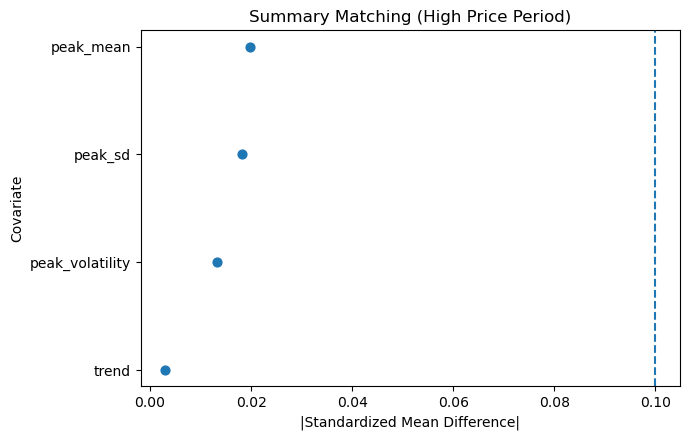

Rebuilding summary profiles for validation...
Matched profiles count = 9918

=== MATCHING VARIABLES ===
+---------------+-------------------+--------------------+---------------------+
|covariate      |treated_mean       |control_mean        |SMD                  |
+---------------+-------------------+--------------------+---------------------+
|peak_mean      |7.001901750846058  |6.936833020185347   |0.01985127609176366  |
|peak_sd        |1.2611262996540729 |1.2438381571173809  |0.01825849164444681  |
|peak_volatility|0.9723585649485715 |0.9641571602649023  |0.013328321281902734 |
|trend          |0.03858782682655395|0.037617799197749456|0.0029628113022103597|
+---------------+-------------------+--------------------+---------------------+


--------------------------------------------------

=== NON-MATCHING VARIABLES (MAIN VALIDATION) ===
+--------------------+------------------+------------------+--------------------+
|covariate           |treated_mean      |control_mean      |SMD

In [10]:
print("Running seasonal summary matching...")

res_summary_season = run_summary_matching_pipeline(
    sdf=month_result_spark,
    output_folder="Files/output/matching/summary_season",
    lookback_months=24,
    match_months=[1,2,3,11,12],
    summary_vars=[
        "peak_mean",
        "peak_sd",
        "peak_volatility",
        "trend"
    ],
    verbose=True,
    save_output=False,
    control_type="never_treated"
)

# res_summary_season["balance"].show(5)

save_matching_results_fabric(
    res=res_summary_season,
    folder="Files/output/matching/summary_season",
    config={
        "type": "summary_season",
        "match_months": [1,2,3,11,12]
    },
)

love_plot_from_spark(
    res_summary_season["balance"],
    output_path=None, 
    title="Summary Matching (High Price Period)"
)

check_balance_full_safe(res_summary_season)

StatementMeta(, a57580c7-f5c0-4acb-8eeb-e0abfe7b7b4f, 17, Finished, Available, Finished, False)

Running calendar matching...
Running calendar-aligned matching...
Preparing base dataframe ...
Building risk set rows ...
risk_rows count = 4732751
+----------+-------+------+
|Ti        |group  |count |
+----------+-------+------+
|2025-03-01|control|471053|
|2025-03-01|treated|6237  |
|2025-04-01|control|471629|
|2025-04-01|treated|3340  |
|2025-05-01|control|471629|
|2025-05-01|treated|1400  |
|2025-06-01|control|471629|
|2025-06-01|treated|1250  |
|2025-07-01|control|471629|
|2025-07-01|treated|640   |
|2025-08-01|control|471629|
|2025-08-01|treated|400   |
|2025-09-01|control|471629|
|2025-09-01|treated|490   |
|2025-10-01|control|471629|
|2025-10-01|treated|500   |
|2025-11-01|control|471629|
|2025-11-01|treated|1464  |
|2025-12-01|control|471735|
|2025-12-01|treated|1210  |
+----------+-------+------+

Building calendar-aligned profiles ...
profiles count = 473665
Standardizing by controls ...
profiles_z count = 473665
Matching top-k (allow missing) ...
matches count = 8475
Buil

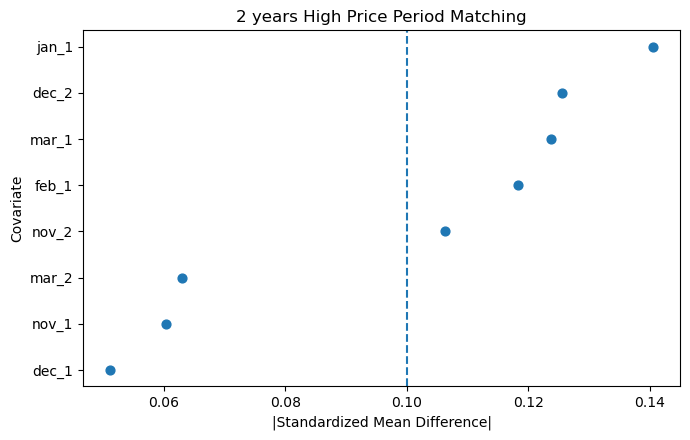

Rebuilding summary profiles for validation...
Matched profiles count = 5541

(No matching variables available in summary space)

--------------------------------------------------

=== NON-MATCHING VARIABLES (MAIN VALIDATION) ===
+--------------------+------------------+-------------------+---------------------+
|covariate           |treated_mean      |control_mean       |SMD                  |
+--------------------+------------------+-------------------+---------------------+
|peak_mean           |7.003955183737412 |6.646534539525193  |0.10097036125194417  |
|peak_sd             |1.2609792472735653|0.9609812612982745 |0.3189570566117875   |
|peak_volatility     |0.9716720508275974|0.7482252065914698 |0.3820627624544767   |
|mean_consumption    |1.9796448789717234|1.9907047193225094 |-0.009519770551769809|
|variance_consumption|2.007833686150713 |1.7882699412625105 |0.11191182846353526  |
|total_consumption   |38409.57126489677 |36513.48620462819  |0.0882956752975987   |
|trend        

In [15]:
print("Running calendar matching...")

res_calendar = run_calendar_matching_aligned(
    sdf=month_result_spark,
    output_folder="Files/output/matching/calendar",
    lookback_years=2,
    match_months=[1,2,3,11,12],
    verbose=True,
    save_output=False,
    control_type="never_treated"
)

# res_calendar["balance"].show(5)

save_matching_results_fabric(
    res=res_calendar,
    folder="Files/output/matching/calendar",
    config={
        "type": "calendar",
        "match_months": [1,2,3,11,12]
    },
)

love_plot_from_spark(
    res_calendar["balance"],
    output_path=None, 
    title="2 years High Price Period Matching"
)

check_balance_full_safe(res_calendar)

StatementMeta(, a57580c7-f5c0-4acb-8eeb-e0abfe7b7b4f, 18, Finished, Available, Finished, False)

Running calendar matching...
Running calendar-aligned matching...
Preparing base dataframe ...
Building risk set rows ...
risk_rows count = 4732751
+----------+-------+------+
|Ti        |group  |count |
+----------+-------+------+
|2025-03-01|control|471053|
|2025-03-01|treated|6237  |
|2025-04-01|control|471629|
|2025-04-01|treated|3340  |
|2025-05-01|control|471629|
|2025-05-01|treated|1400  |
|2025-06-01|control|471629|
|2025-06-01|treated|1250  |
|2025-07-01|control|471629|
|2025-07-01|treated|640   |
|2025-08-01|control|471629|
|2025-08-01|treated|400   |
|2025-09-01|control|471629|
|2025-09-01|treated|490   |
|2025-10-01|control|471629|
|2025-10-01|treated|500   |
|2025-11-01|control|471629|
|2025-11-01|treated|1464  |
|2025-12-01|control|471735|
|2025-12-01|treated|1210  |
+----------+-------+------+

Building calendar-aligned profiles ...
profiles count = 473665
Standardizing by controls ...
profiles_z count = 473665
Matching top-k (allow missing) ...
matches count = 5085
Buil

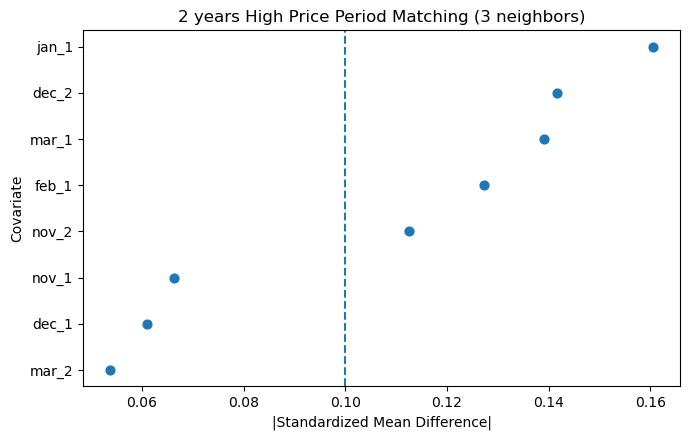

Rebuilding summary profiles for validation...
Matched profiles count = 3676

(No matching variables available in summary space)

--------------------------------------------------

=== NON-MATCHING VARIABLES (MAIN VALIDATION) ===
+--------------------+------------------+-------------------+--------------------+
|covariate           |treated_mean      |control_mean       |SMD                 |
+--------------------+------------------+-------------------+--------------------+
|peak_mean           |7.003955183737413 |6.626915159344128  |0.10530803603270197 |
|peak_sd             |1.2609792472735653|0.9370082196623123 |0.345595897620342   |
|peak_volatility     |0.9716720508275973|0.7604490723077572 |0.34885410666606276 |
|mean_consumption    |1.9796448789717231|1.9517131317783611 |0.02406075860422966 |
|variance_consumption|2.0078336861507124|1.82310488542283   |0.09392841293901136 |
|total_consumption   |38409.57126489675 |34030.56654820797  |0.20567401506552996 |
|trend               |0

In [16]:
print("Running calendar matching...")

res_calendar2 = run_calendar_matching_aligned(
    sdf=month_result_spark,
    output_folder="Files/output/matching/calendar2",
    lookback_years=2,
    match_months=[1,2,3,11,12],
    verbose=True,
    save_output=False,
    control_type="never_treated",
    k_neighbors=3
    
)


save_matching_results_fabric(
    res=res_calendar2,
    folder="Files/output/matching/calendar2",
    config={
        "type": "calendar",
        "match_months": [1,2,3,11,12]
    },
)

love_plot_from_spark(
    res_calendar2["balance"],
    output_path=None, 
    title="2 years High Price Period Matching (3 neighbors)"
)

check_balance_full_safe(res_calendar2)

StatementMeta(, a57580c7-f5c0-4acb-8eeb-e0abfe7b7b4f, 14, Finished, Available, Finished, False)

Running summary matching 4...
Preparing base dataframe ...
Building risk set rows ...
risk_rows count = 5684081
+----------+-------+------+
|Ti        |group  |count |
+----------+-------+------+
|2025-03-01|control|566104|
|2025-03-01|treated|7495  |
|2025-04-01|control|566173|
|2025-04-01|treated|4008  |
|2025-05-01|control|566246|
|2025-05-01|treated|1680  |
|2025-06-01|control|566314|
|2025-06-01|treated|1500  |
|2025-07-01|control|566371|
|2025-07-01|treated|768   |
|2025-08-01|control|566423|
|2025-08-01|treated|480   |
|2025-09-01|control|566472|
|2025-09-01|treated|588   |
|2025-10-01|control|566514|
|2025-10-01|treated|600   |
|2025-11-01|control|566547|
|2025-11-01|treated|1773  |
|2025-12-01|control|566573|
|2025-12-01|treated|1452  |
+----------+-------+------+

Building summary profiles ...
profiles count = 473947
Standardizing by controls ...
profiles_z count = 473947
Matching top-k ...
matches count = 8480
Building matched profiles ...
matched_profiles count = 9718
Compu

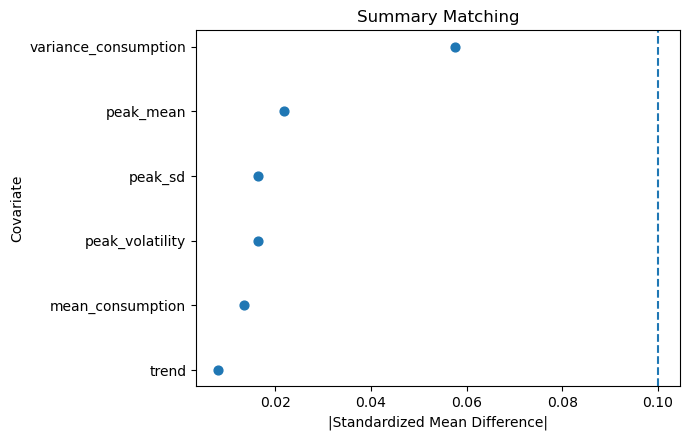

Rebuilding summary profiles for validation...
Matched profiles count = 9718

=== MATCHING VARIABLES ===
+--------------------+-------------------+-------------------+---------------------+
|covariate           |treated_mean       |control_mean       |SMD                  |
+--------------------+-------------------+-------------------+---------------------+
|peak_mean           |6.3093479367395755 |6.240096043534006  |0.021893087460565997 |
|peak_sd             |1.408372294048179  |1.3924838960565593 |0.016423551786183637 |
|peak_volatility     |0.9089504211513721 |0.8995592292598765 |0.016346505436642338 |
|mean_consumption    |1.337627547559283  |1.3465933112680366 |-0.013395919435631861|
|variance_consumption|1.6668940160750698 |1.5744779380493996 |0.05754943463505725  |
|trend               |0.09942157383354666|0.09724757888222879|0.008056180076686226 |
+--------------------+-------------------+-------------------+---------------------+


--------------------------------------------

In [12]:
print("Running summary matching 4...")

res_summary_4 = run_summary_matching_pipeline(
    sdf=month_result_spark,
    output_folder="Files/output/matching/summary_4",
    lookback_months=12,
    summary_vars=[
    "peak_mean",
    "peak_sd",
    "peak_volatility",
    "mean_consumption",
    "variance_consumption",
    "trend"
    ],
    verbose=True,
    save_output=False,
    control_type="never_treated"
)

# res_summary_3["balance"].show(5)

save_matching_results_fabric(
    res=res_summary_4,
    folder="Files/output/matching/summary_4",
    config={
        "type": "summary",
        "vars": ["peak_mean","peak_sd", "peak_volatility", "mean_consumption", "variance_consumption","trend"]
    },
)

love_plot_from_spark(
    res_summary_4["balance"],
    output_path=None, 
    title="Summary Matching"
)

check_balance_full_safe(res_summary_4)

StatementMeta(, a57580c7-f5c0-4acb-8eeb-e0abfe7b7b4f, 15, Finished, Available, Finished, False)

Running seasonal summary matching...
Preparing base dataframe ...
Building risk set rows ...
risk_rows count = 4732751
+----------+-------+------+
|Ti        |group  |count |
+----------+-------+------+
|2025-03-01|control|471053|
|2025-03-01|treated|6237  |
|2025-04-01|control|471629|
|2025-04-01|treated|3340  |
|2025-05-01|control|471629|
|2025-05-01|treated|1400  |
|2025-06-01|control|471629|
|2025-06-01|treated|1250  |
|2025-07-01|control|471629|
|2025-07-01|treated|640   |
|2025-08-01|control|471629|
|2025-08-01|treated|400   |
|2025-09-01|control|471629|
|2025-09-01|treated|490   |
|2025-10-01|control|471629|
|2025-10-01|treated|500   |
|2025-11-01|control|471629|
|2025-11-01|treated|1464  |
|2025-12-01|control|471735|
|2025-12-01|treated|1210  |
+----------+-------+------+

Building summary profiles ...
profiles count = 473798
Standardizing by controls ...
profiles_z count = 473798
Matching top-k ...
matches count = 8480
Building matched profiles ...
matched_profiles count = 977

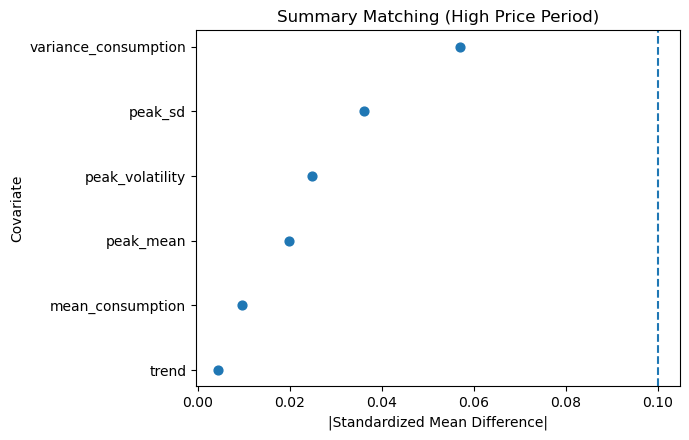

Rebuilding summary profiles for validation...
Matched profiles count = 9770

=== MATCHING VARIABLES ===
+--------------------+--------------------+--------------------+---------------------+
|covariate           |treated_mean        |control_mean        |SMD                  |
+--------------------+--------------------+--------------------+---------------------+
|peak_mean           |7.001901750846059   |6.936410992549814   |0.01984352452537158  |
|peak_sd             |1.2611262996540729  |1.2270575643331854  |0.036110785204428376 |
|peak_volatility     |0.9723585649485718  |0.9572513088606975  |0.024675061192120946 |
|mean_consumption    |1.9795448067888504  |1.989385210327071   |-0.009591124436545867|
|variance_consumption|2.0071671369956054  |1.9000162573682642  |0.05696425887421995  |
|trend               |0.038587826826553956|0.037172224916921036|0.004333073819157904 |
+--------------------+--------------------+--------------------+---------------------+


------------------------

In [13]:
print("Running seasonal summary matching...")

res_summary_season2 = run_summary_matching_pipeline(
    sdf=month_result_spark,
    output_folder="Files/output/matching/summary_season_2",
    lookback_months=24,
    match_months=[1,2,3,11,12],
    summary_vars=[
    "peak_mean",
    "peak_sd",
    "peak_volatility",
    "mean_consumption",
    "variance_consumption",
    "trend"
    ],
    verbose=True,
    save_output=False,
    control_type="never_treated"
)

# res_summary_season["balance"].show(5)

save_matching_results_fabric(
    res=res_summary_season2,
    folder="Files/output/matching/summary_season2",
    config={
        "type": "summary_season",
        "match_months": [1,2,3,11,12],
        "vars": ["peak_mean","peak_sd", "peak_volatility", "mean_consumption", "variance_consumption","trend"]

    },
)

love_plot_from_spark(
    res_summary_season2["balance"],
    output_path=None, 
    title="Summary Matching (High Price Period)"
)

check_balance_full_safe(res_summary_season2)